# Data Initialization

In [1]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt

In [16]:
response_raw_df = pd.read_csv("../data/raw_files/usgs_response_test.csv")
response_raw_df = response_raw_df.drop(['Unnamed: 0'], axis=1)
response_raw_df

,agency_cd,site_no,datetime,219530_00010_00001,219530_00010_00001_cd,219535_00010_00002,219535_00010_00002_cd,325162_00010_00003,325162_00010_00003_cd,65129_00095_00001,65129_00095_00001_cd,65130_00095_00002,65130_00095_00002_cd,65131_00095_00003,65131_00095_00003_cd
0,5s,15s,20d,14n,10s,14n,10s,14n,10s,14n,10s,14n,10s,14n,10s
1,USGS,04294500,2014-09-30,18.7,A,17.2,A,17.9,A,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,04294500,2014-10-01,17.2,A,15.8,A,16.5,A,179,A,170,A,173,A
3,USGS,04294500,2014-10-02,17.0,A,15.8,A,16.4,A,177,A,170,A,174,A
4,USGS,04294500,2014-10-03,17.3,A,16.5,A,16.9,A,179,A,173,A,175,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001,USGS,04294500,2022-12-27,4.0,A,2.7,A,3.4,A,214,A,191,A,198,A
3002,USGS,04294500,2022-12-28,4.6,A,3.3,A,3.7,A,208,A,190,A,199,A
3003,USGS,04294500,2022-12-29,5.3,A,4.5,A,4.9,A,199,A,186,A,192,A
3004,USGS,04294500,2022-12-30,5.9,A,5.3,A,5.6,A,201,A,187,A,193,A


In [17]:
# USGS NWIS parameters

# List of parameter codes with comments for readability
usgs_params = [
    "00003",  # sensor depth below surface
    "00010",  # water temperature
    "00060",  # discharge / water flow
    "00065",  # water level / gage height
    "00400",  # pH
    "00095",  # specific conductance (proxy for salinity)
    # Tests
    # "00059",  # specific conductance (proxy for salinity)
    # "00061",  # specific conductance (proxy for salinity)
    # "00403",  # specific conductance (proxy for salinity)
    # "00408",  # specific conductance (proxy for salinity)
]

# Dictionary of parameter codes and names
usgs_param_names = {
    "00003": "Sensor Depth (ft)",
    "00010": "Water Temp (°C)",
    "00060": "Discharge (cfs)",
    "00065": "Water Level (ft)",
    "00400": "pH",
    "00095": "Specific Conductance (muS/cm)",
    "00059": "Test2",
    "00061": "Test3",
    "00403": "Test4",
    "00408": "Test5",
}

# Convert to string for the API request
param_codes = ",".join(usgs_params)
print(param_codes)

site = "04294500"  # Lake Champlain 
start_date = "2012-01-01"
end_date = "2022-12-31"

# Instantaneous values
# url = "https://nwis.waterservices.usgs.gov/nwis/iv/"
# Daily values
url = "https://nwis.waterservices.usgs.gov/nwis/dv/"

00003,00010,00060,00065,00400,00095


In [18]:
# Request parameters

params = {
    "format": "rdb", # rdb = CSV
    "sites": site,
    "parameterCd": param_codes,
    "startDT": start_date,
    "endDT": end_date,
    "siteStatus": "all"
}


In [21]:
# pivot the response data

response_df = response_raw_df.copy()

# Strip whitespace from column names
response_df.columns = response_df.columns.str.strip()

# Convert datetime column safely
# response_df["datetime"] = pd.to_datetime(response_df["datetime"], errors="coerce")
response_df["datetime"] = pd.to_datetime(
    response_df["datetime"], 
    format="%Y-%m-%d",  # matches NWIS date format
    errors="coerce"
)

# Drop rows where datetime could not be parsed (placeholder/code rows)
response_df = response_df.dropna(subset=["datetime"])

# Keep only numeric value columns (ignore _cd/qualifier columns and agency_cd)
value_cols = [c for c in response_df.columns if not c.endswith("_cd") and c not in ["agency_cd", "datetime"]]

# Convert numeric columns safely
for col in value_cols:
    response_df[col] = pd.to_numeric(response_df[col], errors="coerce")

# Keep only datetime + value columns
response_df = response_df[["datetime"] + value_cols].copy()

# Set datetime as index
response_df.set_index("datetime", inplace=True)

# Rename columns to readable parameter names
col_map = {}
for col in value_cols:
    parts = col.split("_")  # sitecode_parametercode_sensor
    param_cd = parts[1]
    if param_cd in usgs_param_names:
        col_map[col] = usgs_param_names[param_cd]
response_df.rename(columns=col_map, inplace=True)

# After renaming columns to readable names
response_df.rename(columns=col_map, inplace=True)

# Collapse any duplicate columns by taking the mean
# response_df = response_df.groupby(response_df.columns, axis=1).mean()

response_df.head()


,site_no,Water Temp (°C),Water Temp (°C),Water Temp (°C),Specific Conductance (muS/cm),Specific Conductance (muS/cm),Specific Conductance (muS/cm)
datetime,,,,,,,
2014-09-30,4294500,18.7,17.2,17.9,NaN,NaN,NaN
2014-10-01,4294500,17.2,15.8,16.5,179.0,170.0,173.0
2014-10-02,4294500,17.0,15.8,16.4,177.0,170.0,174.0
2014-10-03,4294500,17.3,16.5,16.9,179.0,173.0,175.0
2014-10-04,4294500,17.1,16.4,16.8,191.0,161.0,176.0


# Data Exploration

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [26]:
response_df

,site_no,Water Temp (°C),Water Temp (°C),Water Temp (°C),Specific Conductance (muS/cm),Specific Conductance (muS/cm),Specific Conductance (muS/cm)
datetime,,,,,,,
2014-09-30,4294500,18.7,17.2,17.9,NaN,NaN,NaN
2014-10-01,4294500,17.2,15.8,16.5,179.0,170.0,173.0
2014-10-02,4294500,17.0,15.8,16.4,177.0,170.0,174.0
2014-10-03,4294500,17.3,16.5,16.9,179.0,173.0,175.0
2014-10-04,4294500,17.1,16.4,16.8,191.0,161.0,176.0
...,...,...,...,...,...,...,...
2022-12-27,4294500,4.0,2.7,3.4,214.0,191.0,198.0
2022-12-28,4294500,4.6,3.3,3.7,208.0,190.0,199.0
2022-12-29,4294500,5.3,4.5,4.9,199.0,186.0,192.0


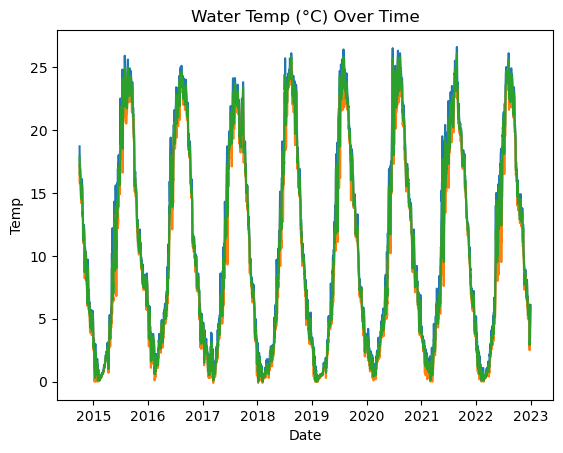

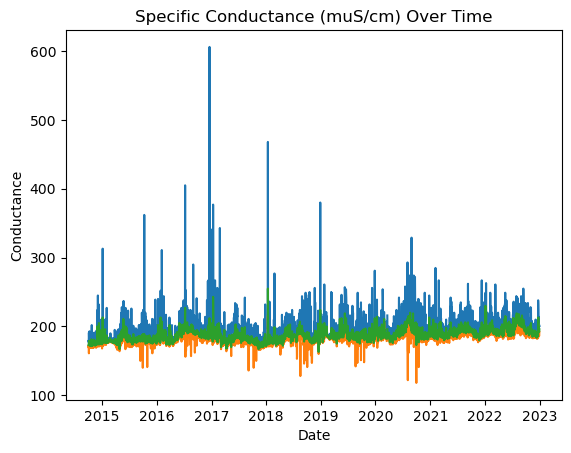

In [27]:
plt.plot(response_df['Water Temp (°C)'])
plt.xlabel("Date")
plt.ylabel("Temp")
plt.title("Water Temp (°C) Over Time")
plt.show()
plt.plot(response_df['Specific Conductance (muS/cm)'])
plt.xlabel("Date")
plt.ylabel("Conductance")
plt.title("Specific Conductance (muS/cm) Over Time")
plt.show()

- blue: site 1
- orange: site 2
- green: site 3

In [37]:
import datetime
import numpy as np

# response_df['Water Temp (°C)']
start_date = "2012-01-01"
end_date = "2022-12-31"

format = '%Y-%m-%d'
start_date = datetime.datetime.strptime(start_date, format)
end_date = datetime.datetime.strptime(end_date, format)
# print(start_date, end_date)

# delta time
delta = datetime.timedelta(days=1)
date_range = int((end_date - start_date).days)

# iterate over range of dates
# while (start_date <= end_date):
#     print(start_date, end="\n")
#     start_date += delta

new_df = pd.DataFrame()
# print(response_df.index)
print(f"{date_range} days in range {start_date} to {end_date}")
count = 0
while (start_date <= end_date):
    if start_date in response_df.index:
        # print(start_date)
        count += 1
    start_date += delta
print(f"{count} days occur")

print(f"{(count/date_range*100):.2f}% of days in our range exist in the dataset")

for i in range(14, 23):
    start_date = f"20{i}-01-01"
    end_date = f"20{i}-12-31"
    start_date = datetime.datetime.strptime(start_date, format)
    end_date = datetime.datetime.strptime(end_date, format)
    
    count = 0
    while (start_date <= end_date):
        if start_date in response_df.index:
            # print(start_date)
            count += 1
        start_date += delta
    print(f"{count} days have data in 20{i}")
    print(f"data fullness for 20{i}: {count/365*100:.2f}%") 

4017 days in range 2012-01-01 00:00:00 to 2022-12-31 00:00:00
3005 days occur
74.81% of days in our range exist in the dataset
93 days have data in 2014
data fullness for 2014: 25.48%
364 days have data in 2015
data fullness for 2015: 99.73%
358 days have data in 2016
data fullness for 2016: 98.08%
365 days have data in 2017
data fullness for 2017: 100.00%
365 days have data in 2018
data fullness for 2018: 100.00%
365 days have data in 2019
data fullness for 2019: 100.00%
365 days have data in 2020
data fullness for 2020: 100.00%
365 days have data in 2021
data fullness for 2021: 100.00%
365 days have data in 2022
data fullness for 2022: 100.00%


In [43]:
# How many NaNs in each column
column_nan_count = response_df.isnull().sum()
print(column_nan_count)

site_no                          0
Water Temp (°C)                  3
Water Temp (°C)                  4
Water Temp (°C)                  5
Specific Conductance (muS/cm)    5
Specific Conductance (muS/cm)    5
Specific Conductance (muS/cm)    5
dtype: int64


In [65]:
for i in df:
    print(f"{i}: {len(df[i].dropna().values)}")

Unnamed: 0: 3006
agency_cd: 3006
site_no: 3006
datetime: 3006
219530_00010_00001: 3003
219530_00010_00001_cd: 3003
219535_00010_00002: 3002
219535_00010_00002_cd: 3002
325162_00010_00003: 3001
325162_00010_00003_cd: 3001
65129_00095_00001: 3001
65129_00095_00001_cd: 3001
65130_00095_00002: 3001
65130_00095_00002_cd: 3001
65131_00095_00003: 3001
65131_00095_00003_cd: 3001


## Conclusions:
- No data before Sept. 2014
- Full reporting after Sept. 2014
- At most 5 days have NaN values
    - 5 NaNs in conductance
    - No more than 5 in Water Temp
    - Spread out evenly, not station dependent
- Conductance varies strongly between stations
- Water temp is roughly consistent across stations

# Preparing 7-day data
- averaging the data across the 3 stations
- including null values for dates without data

In [102]:
water_temp_avg = []
con_avg = []
for i in response_df[['Water Temp (°C)', 'Specific Conductance (muS/cm)']].values:
    water_temp_avg.append(sum(i[0:3]) / 3)
    con_avg.append(sum(i[3:7]) / 3)
    # print(water_avg)
    # print(con_avg)

In [106]:
np.array(response_df.index)

array(['2014-09-30T00:00:00.000000000', '2014-10-01T00:00:00.000000000',
       '2014-10-02T00:00:00.000000000', ...,
       '2022-12-29T00:00:00.000000000', '2022-12-30T00:00:00.000000000',
       '2022-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

In [109]:
data_df = pd.DataFrame({"DateTime": response_df.index, "Water Temp (°C)": water_temp_avg, "Specific Conductance (muS/cm)": con_avg})
data_df

,DateTime,Water Temp (°C),Specific Conductance (muS/cm)
0,2014-09-30,17.933333,NaN
1,2014-10-01,16.500000,174.000000
2,2014-10-02,16.400000,173.666667
3,2014-10-03,16.900000,175.666667
4,2014-10-04,16.766667,176.000000
...,...,...,...
3000,2022-12-27,3.366667,201.000000
3001,2022-12-28,3.866667,199.000000
3002,2022-12-29,4.900000,192.333333
3003,2022-12-30,5.600000,193.666667


In [110]:
# Next Steps:
# Fill in null values for missing days, and decide how to treat nulls in rolling avg.
# perform 1, 3, and 7 day rolling avg. and fill in their columns
# anaylze trends